# Instance Segmentation Cacat Biji Kopi
## YOLOv8s-seg ONLY — Baseline (Apple-to-Apple vs SAFT v2)

**Tujuan:** Baseline murni untuk perbandingan *fair* dengan `fixed_train_model_v2.ipynb`

**Parameter yang disamakan dengan SAFT v2:**

| Parameter | Baseline (lama) | Baseline (revisi) | SAFT v2 |
|---|---|---|---|
| Model | yolov8s-seg | yolov8s-seg | yolov8s-seg |
| `imgsz` | 640 ✅ | 640 ✅ | 640 |
| `batch` | 16 ⚠️ | **8** | 8 |
| `patience` | 15 ⚠️ | **20** | 20 |
| `optimizer` | default (SGD) ⚠️ | **AdamW** | AdamW |
| `lr0` | default ⚠️ | **1e-3** | 1e-3 |
| `amp` | False ⚠️ | **True** | True |
| `epochs` | 100 ✅ | 100 ✅ | 100 |
| `conf inferensi` | 0.5 ⚠️ | **0.25** | 0.25 |
| `iou inferensi` | 0.45 ⚠️ | **0.45** | 0.45 |
| RUN_ID di folder | Ada ⚠️ | **Dihapus** (path statis) | path statis |

> **Catatan:** `RUN_ID` dihapus dari nama folder output agar path `BEST_MODEL_PATH`
> tidak berubah setiap kali kernel di-restart — konsisten dengan SAFT v2.

---


## TAHAP 1 — Instalasi Library & Import

In [1]:
# ==============================================================================
# TAHAP 1: INSTALASI LIBRARY & IMPORT (LOCAL VS CODE)
# ==============================================================================
import subprocess, sys

for pkg in ["ultralytics", "roboflow", "sahi", "shapely",
            "pyyaml", "opencv-python", "matplotlib"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import os, cv2, math, yaml, glob, random, gc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import torch
import platform
from ultralytics import YOLO
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")

# ── Deteksi Jupyter ──
try:
    from IPython import get_ipython as _gip
    _in_jupyter = _gip() is not None
except ImportError:
    _in_jupyter = False

if _in_jupyter:
    matplotlib.use("inline")
    # %matplotlib inline  # uncomment jika di Jupyter
else:
    matplotlib.use("Agg")

# ── Deteksi GPU ──
print(f"PyTorch Version : {torch.__version__}")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    DEVICE       = 0
    DEVICE_STR   = "cuda:0"
else:
    print("⚠️  GPU tidak tersedia — berjalan di CPU.")
    DEVICE       = "cpu"
    DEVICE_STR   = "cpu"

NUM_WORKERS = 0 if platform.system() == "Windows" else 2
HOME        = os.getcwd()
print(f"[INFO] Device      : {DEVICE}")
print(f"[INFO] Working dir : {HOME}")


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


PyTorch Version : 2.11.0+cu130
✅ GPU: NVIDIA GeForce RTX 2060
[INFO] Device      : 0
[INFO] Working dir : /home/lab-ai/riki/baseline


## TAHAP 2 — Download Dataset (Roboflow)

In [2]:
# ==============================================================================
# TAHAP 2: DOWNLOAD DATASET DARI ROBOFLOW
# ==============================================================================
from roboflow import Roboflow

DATASET_PATH = os.path.join(HOME, "defect-coffee-350g-1161-1")
YAML_PATH    = os.path.join(DATASET_PATH, "data.yaml")

if not os.path.exists(YAML_PATH):
    print("[INFO] Dataset belum ada, mendownload...")
    rf      = Roboflow(api_key="XCt1ERaf9Ckc2RB189yo")
    project = rf.workspace("student-i41yd").project("defect-coffee-350g-1161")
    version = project.version(1)
    dataset = version.download("yolov8")
    DATASET_PATH = dataset.location
    YAML_PATH    = os.path.join(DATASET_PATH, "data.yaml")
else:
    print(f"[INFO] Dataset sudah ada, skip download → {DATASET_PATH}")

print(f"[INFO] Dataset : {DATASET_PATH}")
print(f"[INFO] YAML    : {YAML_PATH}")

[INFO] Dataset sudah ada, skip download → /home/lab-ai/riki/baseline/defect-coffee-350g-1161-1
[INFO] Dataset : /home/lab-ai/riki/baseline/defect-coffee-350g-1161-1
[INFO] YAML    : /home/lab-ai/riki/baseline/defect-coffee-350g-1161-1/data.yaml


## TAHAP 3 — Cek Isi Dataset

In [3]:
# ==============================================================================
# TAHAP 3: CEK ISI DATASET
# ==============================================================================
with open(YAML_PATH, "r") as f:
    data_yaml = yaml.safe_load(f)

train_imgs = glob.glob(f"{DATASET_PATH}/train/images/*")
valid_imgs = glob.glob(f"{DATASET_PATH}/valid/images/*")
test_imgs  = glob.glob(f"{DATASET_PATH}/test/images/*")

print("=" * 50)
print("INFO DATASET")
print("=" * 50)
print(f"Jumlah Kelas   : {data_yaml.get('nc', 'N/A')}")
print(f"Nama Kelas     : {data_yaml.get('names', 'N/A')}")
print(f"Train          : {len(train_imgs)} gambar")
print(f"Validasi       : {len(valid_imgs)} gambar")
print(f"Test           : {len(test_imgs)} gambar")

INFO DATASET
Jumlah Kelas   : 16
Nama Kelas     : ['broken', 'cherry pod', 'floater', 'foreign material', 'full black', 'full sour', 'fungus', 'hull', 'immature', 'parchment', 'partial black', 'partial sour', 'severe insect', 'shell', 'slight insect', 'withered']
Train          : 809 gambar
Validasi       : 232 gambar
Test           : 115 gambar


## TAHAP 4 — Training YOLOv8s-seg (Baseline — Apple-to-Apple)

> Semua hyperparameter disamakan persis dengan `fixed_train_model_v2.ipynb` (SAFT v2).  
> Satu-satunya perbedaan: data train adalah **gambar asli** (tanpa SAFT slicing).

In [4]:
# ==============================================================================
# TAHAP 4: TRAINING YOLOv8s-SEG — BASELINE (APPLE-TO-APPLE vs SAFT v2)
# ==============================================================================
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats() if torch.cuda.is_available() else None

if torch.cuda.is_available():
    print(f"VRAM tersedia : {torch.cuda.mem_get_info()[0]/1024**3:.2f} GB")
    print(f"VRAM total    : {torch.cuda.mem_get_info()[1]/1024**3:.2f} GB")

# ── Path output — statis, tanpa RUN_ID agar mudah dirujuk kembali ──
OUTPUT_DIR      = os.path.join(HOME, "coffee_baseline_v2")
TRAIN_NAME      = "yolov8s_seg_baseline"
WEIGHTS_DIR     = os.path.join(OUTPUT_DIR, TRAIN_NAME, "weights")
BEST_MODEL_PATH = os.path.join(WEIGHTS_DIR, "best.pt")
LAST_PT         = os.path.join(WEIGHTS_DIR, "last.pt")
os.makedirs(WEIGHTS_DIR, exist_ok=True)

print("=" * 50)
print("MEMULAI TRAINING YOLOv8s-SEG BASELINE")
print("=" * 50)
print("Hyperparameter (apple-to-apple vs SAFT v2):")
print("  imgsz     = 640")
print("  batch     = 8       ← disamakan (lama: 16)")
print("  epochs    = 100")
print("  optimizer = AdamW   ← disamakan (lama: default SGD)")
print("  lr0       = 1e-3    ← disamakan")
print("  patience  = 20      ← disamakan (lama: 15)")
print("  amp       = True    ← disamakan (lama: False)")
print("  data      = gambar asli (tanpa SAFT)")
print()

# Resume jika last.pt sudah ada
if os.path.exists(LAST_PT):
    print("[INFO] ✅ Ditemukan last.pt — RESUME training...")
    model_seg = YOLO(LAST_PT)
    results = model_seg.train(
        resume  = True,
        device  = DEVICE,
        workers = NUM_WORKERS,
        verbose = True
    )
else:
    print("[INFO] Mulai training baru (epoch 1)...")
    model_seg = YOLO("yolov8s-seg.pt")
    results = model_seg.train(
        data      = YAML_PATH,       # ← data ASLI, tanpa SAFT
        epochs    = 60,
        imgsz     = 640,             # ✅ sama dengan SAFT v2
        batch     = 4,               # ✅ sama (lama: 16)
        device    = DEVICE,
        workers   = NUM_WORKERS,
        patience  = 20,              # ✅ sama (lama: 15)
        optimizer = "AdamW",         # ✅ sama (lama: default SGD)
        lr0       = 1e-3,            # ✅ sama
        amp       = True,            # ✅ sama (lama: False)
        save      = True,
        project   = OUTPUT_DIR,
        name      = TRAIN_NAME,
        exist_ok  = True,
        verbose   = True
    )

BEST_MODEL_PATH = os.path.join(WEIGHTS_DIR, "best.pt")
print(f"\n[INFO] Training selesai. Best model: {BEST_MODEL_PATH}")

VRAM tersedia : 3.44 GB
VRAM total    : 5.59 GB
MEMULAI TRAINING YOLOv8s-SEG BASELINE
Hyperparameter (apple-to-apple vs SAFT v2):
  imgsz     = 640
  batch     = 8       ← disamakan (lama: 16)
  epochs    = 100
  optimizer = AdamW   ← disamakan (lama: default SGD)
  lr0       = 1e-3    ← disamakan
  patience  = 20      ← disamakan (lama: 15)
  amp       = True    ← disamakan (lama: False)
  data      = gambar asli (tanpa SAFT)

[INFO] Mulai training baru (epoch 1)...
New https://pypi.org/project/ultralytics/8.4.79 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.48 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2060, 5729MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/lab-ai/riki/baseline/defect-co

## Recovery Cell — Jalankan jika kernel di-restart

In [5]:
# ==============================================================================
# RECOVERY CELL
# ==============================================================================
import os, glob, torch, platform
from ultralytics import YOLO

HOME            = os.getcwd()
OUTPUT_DIR      = os.path.join(HOME, "coffee_baseline_v2")
TRAIN_NAME      = "yolov8s_seg_baseline"
DATASET_PATH    = glob.glob(os.path.join(HOME, "defect-coffee*"))[0]
YAML_PATH       = os.path.join(DATASET_PATH, "data.yaml")
WEIGHTS_DIR     = os.path.join(OUTPUT_DIR, TRAIN_NAME, "weights")
BEST_MODEL_PATH = os.path.join(WEIGHTS_DIR, "best.pt")

DEVICE     = 0   if torch.cuda.is_available() else "cpu"
DEVICE_STR = "cuda:0" if torch.cuda.is_available() else "cpu"
NUM_WORKERS = 0 if platform.system() == "Windows" else 2

print(f"[INFO] Dataset     : {DATASET_PATH}")
print(f"[INFO] YAML        : {YAML_PATH}")
print(f"[INFO] Best model  : {BEST_MODEL_PATH}")
print(f"[INFO] Model exist : {'✅ OK' if os.path.exists(BEST_MODEL_PATH) else '❌ Tidak ditemukan'}")

[INFO] Dataset     : /home/lab-ai/riki/baseline/defect-coffee-350g-cp-1
[INFO] YAML        : /home/lab-ai/riki/baseline/defect-coffee-350g-cp-1/data.yaml
[INFO] Best model  : /home/lab-ai/riki/baseline/coffee_baseline_v2/yolov8s_seg_baseline/weights/best.pt
[INFO] Model exist : ✅ OK


## TAHAP 4B — Kurva Training

[INFO] Training results dir: /home/lab-ai/riki/baseline/coffee_baseline_v2/yolov8s_seg_baseline
── results.png ──


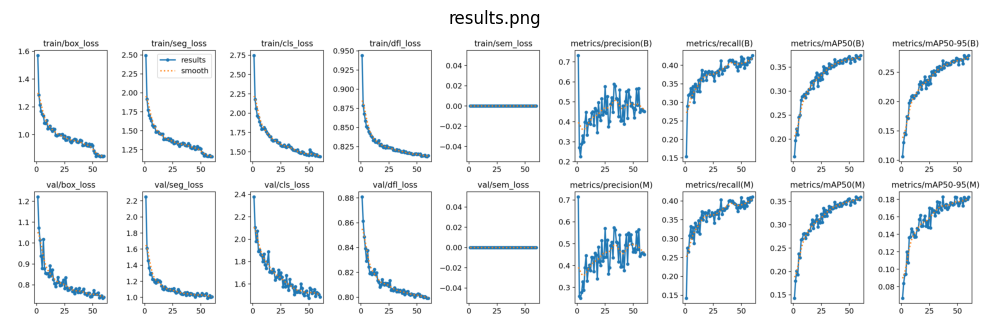

[WARNING] F1_curve.png tidak ditemukan.
[WARNING] P_curve.png tidak ditemukan.
[WARNING] R_curve.png tidak ditemukan.
[WARNING] PR_curve.png tidak ditemukan.


In [6]:
# ==============================================================================
# TAHAP 4B: KURVA TRAINING
# ==============================================================================
train_dir = os.path.join(OUTPUT_DIR, TRAIN_NAME)
print(f"[INFO] Training results dir: {train_dir}")

for curve_file in ["results.png", "F1_curve.png", "P_curve.png",
                   "R_curve.png", "PR_curve.png"]:
    curve_path = os.path.join(train_dir, curve_file)
    if os.path.exists(curve_path):
        print(f"── {curve_file} ──")
        img_c = cv2.cvtColor(cv2.imread(curve_path), cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 6))
        plt.imshow(img_c)
        plt.title(curve_file)
        plt.axis("off")
        plt.tight_layout()
        plt.savefig(os.path.join(train_dir, f"preview_{curve_file}"),
                    dpi=100, bbox_inches="tight")
        plt.show()
        plt.close()
    else:
        print(f"[WARNING] {curve_file} tidak ditemukan.")

## TAHAP 5 — Evaluasi Model (mAP, IoU, Confusion Matrix)

Ultralytics 8.4.48 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2060, 5729MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,785,792 parameters, 0 gradients, 40.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3.7±1.7 MB/s, size: 318.7 KB)
val: Scanning /home/lab-ai/riki/baseline/defect-coffee-350g-cp-1/test/labels.cache... 115 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 115/115 68.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.2s/it 17.3s0.7ss
                   all        115       9913      0.508      0.425      0.399      0.302      0.502      0.414      0.383      0.186
                broken         88       1275      0.393      0.259      0.217      0.172      0.388      0.252      0.214      0.107
            cherry pod         20         32      0.433       0.75      0.622      0.534      0.446       0.75      0.622      0.3

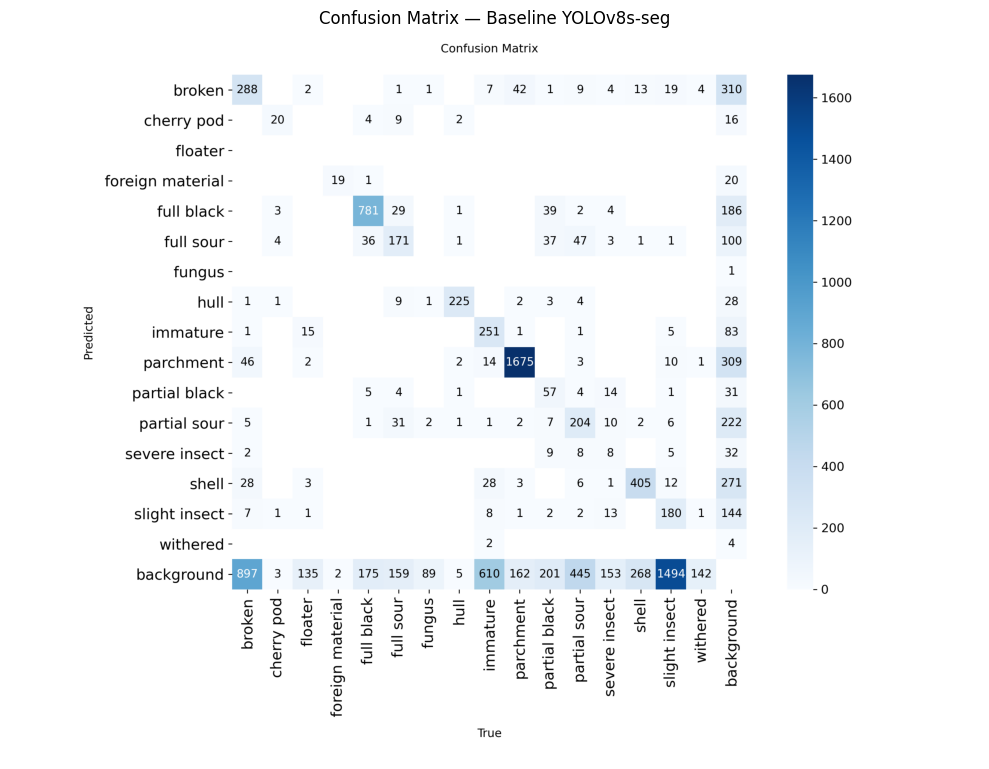

In [7]:
# ==============================================================================
# TAHAP 5: EVALUASI MODEL (DATA TEST)
# ==============================================================================
best_model = YOLO(BEST_MODEL_PATH)

metrics = best_model.val(
    data    = YAML_PATH,
    split   = "test",
    device  = DEVICE,
    workers = NUM_WORKERS
)

mask_metrics = metrics.seg
print("=" * 50)
print("HASIL METRIK EVALUASI — MASK (SEGMENTASI)")
print("=" * 50)
print(f"mAP @ IoU=0.50      : {mask_metrics.map50:.4f}")
print(f"mAP @ IoU=0.50:0.95 : {mask_metrics.map:.4f}")
print(f"Precision (Mask)    : {mask_metrics.mp:.4f}")
print(f"Recall (Mask)       : {mask_metrics.mr:.4f}")

cm_path = os.path.join(str(metrics.save_dir), "confusion_matrix.png")
if os.path.exists(cm_path):
    cm_img = cv2.cvtColor(cv2.imread(cm_path), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm_img)
    plt.title("Confusion Matrix — Baseline YOLOv8s-seg")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(str(metrics.save_dir), "confusion_matrix_preview.png"),
                dpi=100, bbox_inches="tight")
    plt.show()
    plt.close()

## TAHAP 6 — Inferensi & Visualisasi Hasil Segmentasi

In [ ]:
# ==============================================================================
# TAHAP 6: INFERENSI YOLOv8-SEG & VISUALISASI (conf=0.25 — apple-to-apple)
# ==============================================================================
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

best_model = YOLO(BEST_MODEL_PATH)

VIZ_OUTPUT_DIR = os.path.join(OUTPUT_DIR, "inferensi_visualisasi")
os.makedirs(VIZ_OUTPUT_DIR, exist_ok=True)

test_images   = glob.glob(f"{DATASET_PATH}/test/images/*.jpg")
sample_images = random.sample(test_images, min(5, len(test_images)))

for img_path in sample_images:
    # Inferensi di GPU
    with torch.no_grad():
        result = best_model.predict(
            source       = img_path,
            imgsz        = 640,
            conf         = 0.25,
            iou          = 0.45,
            retina_masks = True,
            device       = DEVICE_STR,
            verbose      = False
        )[0]

    # Pindahkan semua tensor ke CPU sebelum plot
    # result.plot() memanggil annotator.masks() yang butuh VRAM besar
    result = result.cpu()
    if result.masks is not None:
        result.masks.data = result.masks.data.cpu()

    # im_gpu=None memaksa rendering di CPU, tidak pakai VRAM
    annotated_img = result.plot(im_gpu=None)
    annotated_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    save_path = os.path.join(VIZ_OUTPUT_DIR, os.path.basename(img_path))
    cv2.imwrite(save_path, annotated_img)

    plt.figure(figsize=(10, 8))
    plt.imshow(annotated_rgb)
    plt.title(f"Baseline Seg: {os.path.basename(img_path)}")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(save_path.replace(".jpg", "_preview.png"), dpi=100, bbox_inches="tight")
    plt.show()
    plt.close()

    del result, annotated_img, annotated_rgb
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"[INFO] Visualisasi disimpan di: {VIZ_OUTPUT_DIR}")

NameError: name 'DATASET_PATH' is not defined

## TAHAP 7 — SCA Grading (conf=0.25 — apple-to-apple)

In [ ]:
# ==============================================================================
# TAHAP 7: INFERENSI + PERHITUNGAN GRADING SCA
# conf=0.25 disamakan dengan SAFT v2 (lama: 0.5)
# SCA_RULES disamakan persis dengan SAFT v2
# ==============================================================================

# ── Pilih gambar test pertama secara otomatis ──
test_images_all = sorted(glob.glob(os.path.join(DATASET_PATH, "test", "images", "*.jpg")))
assert len(test_images_all) > 0, "Tidak ada gambar di folder test!"
test_image_path = test_images_all[0]
print(f"[INFO] Gambar: {os.path.basename(test_image_path)}")

# ── Inferensi ──
result = best_model.predict(
    source       = test_image_path,
    conf         = 0.25,    # ✅ disamakan (lama: 0.5)
    iou          = 0.45,
    retina_masks = True,
    device       = DEVICE_STR,
    verbose      = False
)[0]

annotated_img = result.plot()
annotated_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(14, 10))
plt.imshow(annotated_rgb)
plt.title(f"Baseline — {os.path.basename(test_image_path)}")
plt.axis("off")
plt.tight_layout()
grading_out = os.path.join(OUTPUT_DIR, "grading_result_baseline.png")
plt.savefig(grading_out, dpi=100, bbox_inches="tight")
plt.show()
plt.close()
print(f"[INFO] Hasil disimpan: {grading_out}")

# ── Hitung instance per kelas ──
defect_counts = {}
class_names   = result.names
if result.boxes is not None and len(result.boxes) > 0:
    for cls_id in result.boxes.cls.cpu().numpy().astype(int):
        cn = class_names[cls_id]
        defect_counts[cn] = defect_counts.get(cn, 0) + 1

print("\n--- Deteksi Cacat ---")
for k, v in defect_counts.items():
    print(f"  {k}: {v} biji")

# ==============================================================================
# SCA_RULES — identik dengan SAFT v2 (severe insect: kat1, divisor=5)
# ==============================================================================
SCA_RULES = {
    # Kategori 1 (Primer)
    "full black"    : {"kategori": 1, "divisor": 1},
    "full sour"     : {"kategori": 1, "divisor": 1},
    "fungus"        : {"kategori": 1, "divisor": 1},
    "foreign matter": {"kategori": 1, "divisor": 1},
    "cherry pod"    : {"kategori": 1, "divisor": 1},
    "severe insect" : {"kategori": 1, "divisor": 5},   # ✅ kat1, div=5
    # Kategori 2 (Sekunder)
    "partial black" : {"kategori": 2, "divisor": 3},
    "partial sour"  : {"kategori": 2, "divisor": 3},
    "parchment"     : {"kategori": 2, "divisor": 5},
    "broken"        : {"kategori": 2, "divisor": 5},
    "withered"      : {"kategori": 2, "divisor": 5},
    "immature"      : {"kategori": 2, "divisor": 5},
    "hull"          : {"kategori": 2, "divisor": 5},
    "shell"         : {"kategori": 2, "divisor": 5},
    "floater"       : {"kategori": 2, "divisor": 5},
    "slight insect" : {"kategori": 2, "divisor": 10},
}

def determine_sca_grade(counts, rules, image_name=""):
    cat1_tdc = 0.0
    cat2_tdc = 0.0

    print("\n" + "=" * 55)
    print("       ☕ SCA COFFEE DEFECT GRADING REPORT")
    print("=" * 55)
    if image_name:
        print(f"  File : {image_name}")
    print("-" * 55)

    print("\n  [KATEGORI 1 — PRIMARY DEFECTS]")
    for defect_name, count in sorted(counts.items()):
        key = defect_name.lower().strip()
        if key not in rules or rules[key]["kategori"] != 1:
            continue
        tdc = math.floor(count / rules[key]["divisor"])
        print(f"    {defect_name:22s}: {count:3d} / {rules[key]['divisor']:2d} = {tdc} TDC")
        cat1_tdc += tdc

    print("\n  [KATEGORI 2 — SECONDARY DEFECTS]")
    for defect_name, count in sorted(counts.items()):
        key = defect_name.lower().strip()
        if key not in rules or rules[key]["kategori"] != 2:
            continue
        tdc = math.floor(count / rules[key]["divisor"])
        print(f"    {defect_name:22s}: {count:3d} / {rules[key]['divisor']:2d} = {tdc} TDC")
        cat2_tdc += tdc

    unknown = [k for k in counts if k.lower().strip() not in rules]
    if unknown:
        print("\n  [TIDAK DIKENAL — diabaikan]")
        for u in unknown:
            print(f"    {u}")

    print("\n" + "-" * 55)
    print(f"  Total TDC Kategori 1 : {cat1_tdc:.0f}")
    print(f"  Total TDC Kategori 2 : {cat2_tdc:.0f}")
    print("-" * 55)

    if cat1_tdc == 0 and cat2_tdc <= 5:
        grade = "SPECIALTY GRADE ✅"
    else:
        grade = "BELOW SPECIALTY GRADE ❌"

    print(f"\n  KESIMPULAN: {grade}")
    print("=" * 55)
    return grade, cat1_tdc, cat2_tdc

final_grade, cat1, cat2 = determine_sca_grade(
    defect_counts, SCA_RULES, os.path.basename(test_image_path)
)

## TAHAP 8 — Inferensi Batch Seluruh Data Test

In [ ]:
# ==============================================================================
# TAHAP 8: INFERENSI BATCH — SELURUH DATA TEST
# conf=0.25 disamakan dengan SAFT v2
# ==============================================================================
print("=" * 50)
print("INFERENSI BATCH - SELURUH DATA TEST")
print("=" * 50)

test_image_dir  = os.path.join(DATASET_PATH, "test", "images")
all_test_images = (glob.glob(f"{test_image_dir}/*.jpg") +
                   glob.glob(f"{test_image_dir}/*.png"))

grade_summary        = defaultdict(int)
total_defect_summary = defaultdict(int)

for img_path in all_test_images:
    res = best_model.predict(
        source       = img_path,
        conf         = 0.25,   # ✅ disamakan (lama: 0.5)
        iou          = 0.45,
        retina_masks = True,
        verbose      = False
    )[0]

    counts = {}
    if res.boxes is not None and len(res.boxes) > 0:
        for cls_id in res.boxes.cls.cpu().numpy().astype(int):
            cn = res.names[cls_id]
            counts[cn] = counts.get(cn, 0) + 1
            total_defect_summary[cn] += 1

    grade, _, _ = determine_sca_grade(counts, SCA_RULES)
    grade_summary[grade] += 1

print("\n--- Rekap Grading Seluruh Gambar Test ---")
for grade, count in grade_summary.items():
    print(f"  {grade}: {count} gambar")

print("\n--- Total Deteksi Cacat Per Kelas ---")
for defect, total in sorted(total_defect_summary.items(), key=lambda x: -x[1]):
    print(f"  {defect:25s}: {total} instance")

## TAHAP 9 — Lokasi Model Terbaik

In [ ]:
# ==============================================================================
# TAHAP 9: LOKASI MODEL TERBAIK
# ==============================================================================
print("=" * 50)
print("LOKASI MODEL TERBAIK (best.pt)")
print("=" * 50)
print(f"Path absolut: {os.path.abspath(BEST_MODEL_PATH)}")

if os.path.exists(BEST_MODEL_PATH):
    size_mb = os.path.getsize(BEST_MODEL_PATH) / (1024 * 1024)
    print(f"Ukuran file  : {size_mb:.2f} MB")
    print("✅ File model berhasil disimpan.")
else:
    print("❌ File model tidak ditemukan. Pastikan training selesai.")